In [1]:
# use redback sn1998bw_template not sncosmo_models 
#still testing model for 98bw 
#take data from online: 

#can i use ebv_mw, target_milky_way_ebv, model_kwarg_names=[], use_set_peak_magnitude = True, peak_abs_mag = -18.6, peak_time = 16 in the 1998bw template ?? 
#are they within kwargs ? 

In [2]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
14:54 bilby INFO    : Running bilby version: 2.3.0
14:54 redback INFO    : Running redback version: 1.12.1


In [3]:
from redback.model_library import all_models_dict

func = all_models_dict['sncosmo_models']

In [4]:
def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)


In [5]:
all_models_dict['sn1998bw_template'] = sn1998bw_template

func1 = all_models_dict['sn1998bw_template']

In [6]:
#GRB info:
#NOTE! paper  online says extinction a_v = 0.2 
#our value of E(B-V) =0.059 means a_v = 0.18 so almost 2 !! 
#from paper the apartnt magnitude in B band = 14.09 at day 10.2 ? 
#use this info as a datapoint and see how it compares 

times = np.geomspace(0.01,90,200)
target_frequencies = 6.86300e+14 # B band (FROM REDBACK FILTERS)
target_milky_way_ebv = 0.059
target_redshift = 0.0085 #redshift of 1998bw 

#values from paper 
# AB_mag = 14.09  - 0.09 #B band correction ?? include ?? makes ratio correct ? -- 
# time = np.array((10.2))
# wavelength = np.array([4371.07000]) #angstroms

# #to get a_v from E(B-V) 
# a_v = target_milky_way_ebv * 3.1 

#maybe use my own values instead to get right ratio for this datapoint ? 
AB_mag = 14.370000000000001 - 0.09 #B band correction 
#have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working --YES 
target_obs_times = np.array([10.420000000074506, 10.420000000074506]) #days in observer frame 
time = np.array((10.420000000074506))
target_redshift = 0.0085
wavelength = np.array([4371.07000]) #angstroms
#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 



In [7]:
sn_1998bw1= func1(time=time,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#now interpolate for one time to compare ~ 10.2 days 

In [8]:
#now use info from online to do de-reddening and find flux density

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

This is the flux density of  GRB event without extinction correction: 7.04693 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 8.79830 mJy


In [9]:
#now take final ratio using new improve sn199bw_template model 
flux_ratio = dereddened_flux_event / sn_1998bw1
print("The final f_98 ratio =", flux_ratio.to_value())
#1 my values work !! 

The final f_98 ratio = [1.04681513]


In [10]:
#now test the same for a later time: 

AB_mag2 = 15.96 - 0.09 #B band correction 
#have to use two frequencies or two time points - pass in the same time point twice
target_obs_times = np.array([37.46000000011176, 37.46000000011176]) #days in observer frame 
target_redshift = 0.0085
target_frequencies = 6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059 

#try with new function: 

all_models_dict['sn1998bw_template'] = sn1998bw_template

func1 = all_models_dict['sn1998bw_template']

#specify a time !! 
time2 = np.array((37.46000000011176))

sn_1998bw1= func1(time=time2,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )


#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag2):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag2 * uu.ABmag).to(uu.mJy)

flux_density_event2 = calc_flux_density_from_ABmag(AB_mag2)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event2:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event2 = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event2) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event2[0]:.5f}")

flux_ratio = dereddened_flux_event2[0] / sn_1998bw1

print("The final f_98 ratio =", flux_ratio.to_value())


This is the flux density of  GRB event without extinction correction: 1.62930 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 2.03422 mJy
The final f_98 ratio = [1.03826556]


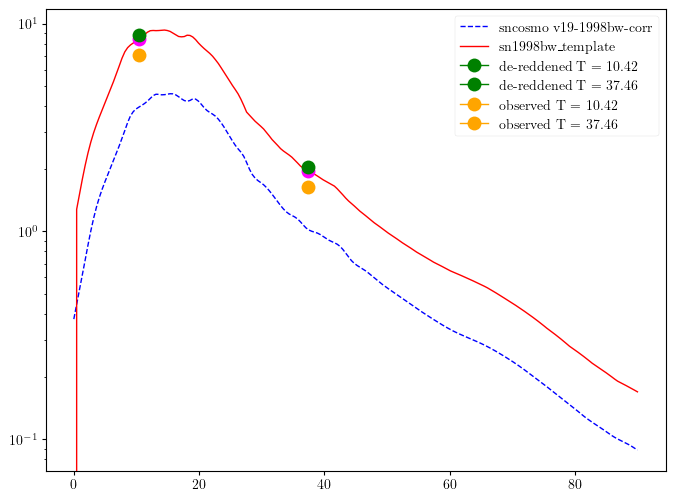

In [11]:
#GRB info
freq = target_frequencies
redshift = target_redshift
times = np.linspace(0.01,90,200)
#time = target_obs_times

sn_1998bw = func(time=times,
    redshift=redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)

#now use this as the SN1998bw lightcueve and the above as the GRB event with redshift defined 
# sn_1998bw1= func(time=times,
#     redshift=0.0085,
#     model_kwargs=None,
#     sncosmo_model='v19-1998bw-corr',
#     output_format='flux_density', # Returns mJy
#     frequency=target_frequencies,
#     mw_extinction=True,           # Add MW dust for YOUR target
#     ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
#     model_kwarg_names=[], 
#     use_set_peak_magnitude = True,
#     peak_abs_mag = -18.6,
#     peak_time = 16 #shifts pak time to where it actually is 
# )

#replace with 1998bw_template: 
sn_1998bw1= func1(time=times,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#make new functions for specific times to bcompare the baseline points on the plot


sn_1998bw1_t1= func1(time=time,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

sn_1998bw1_t2= func1(time=time2,
                redshift=0.0085,
                model_kwargs=None,
                amplitude = 1,
                output_format='flux_density', # Returns mJy
                frequency=target_frequencies,
                mw_extinction=True,
                # Add MW dust for YOUR target
                ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                model_kwarg_names=[],
                use_set_peak_magnitude = True,
                peak_abs_mag = -18.6, #-18.88 B band ? 
                peak_time = 16 #shifts pak time to where it actually is
                )
plt.figure(figsize = (8,6))
plt.semilogy(times,sn_1998bw,'-b', linestyle = '--', label = 'sncosmo v19-1998bw-corr')
plt.semilogy(times,sn_1998bw1, '-r', label = 'sn1998bw_template')
#how do i get these other values to work ?? 
plt.semilogy(time, sn_1998bw1_t1, marker='o',color='magenta', markersize = 10) #fluxes interpolated from model - can see -- get rid of green then see ? 
plt.semilogy(time2, sn_1998bw1_t2, marker='o',color='magenta', markersize = 10)
plt.semilogy(time, dereddened_flux_event[0], marker='o',color='green', markersize = 10, label = 'de-reddened T = 10.42') #dereddened flux density points for GRB event 
plt.semilogy(time2, dereddened_flux_event2[0], marker='o',color='green', markersize = 10, label = 'de-reddened T = 37.46')
plt.semilogy(time, flux_density_event, marker='o',color='orange', markersize = 10, label = 'observed T = 10.42') #observed (reddened) flux density points for GRB event -- issue with this point -- re run ? -- fixed !! 
plt.semilogy(time2, flux_density_event2, marker='o',color='orange', markersize = 10, label = 'observed T = 37.46')
plt.legend()
plt.show()

In [12]:
#test this function with other GRBs and see if they work too 